# Análisis estadístico

Necesitamos probar que las diferencias que vemos no son por suerte. Aquí hacemos eso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, mannwhitneyu

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14,6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/BankChurners.csv').iloc[:, :-2]

¿Qué hacen los clientes que se van?

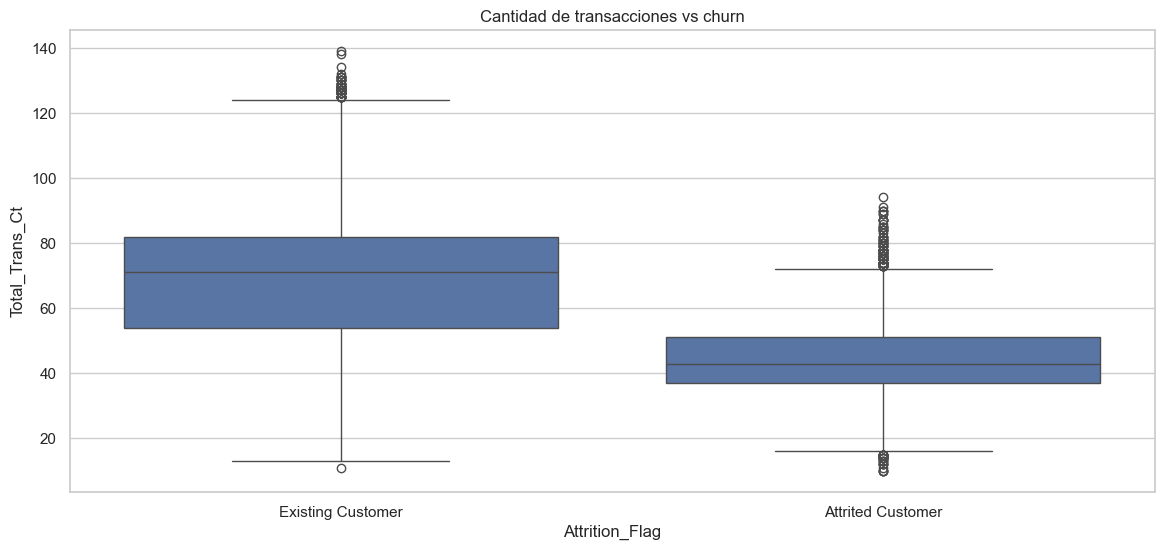

In [2]:
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df)
plt.title('Cantidad de transacciones vs churn')
plt.show()

Hay una diferencia clara. Los que se van hacen menos transacciones. Eso es un patrón.

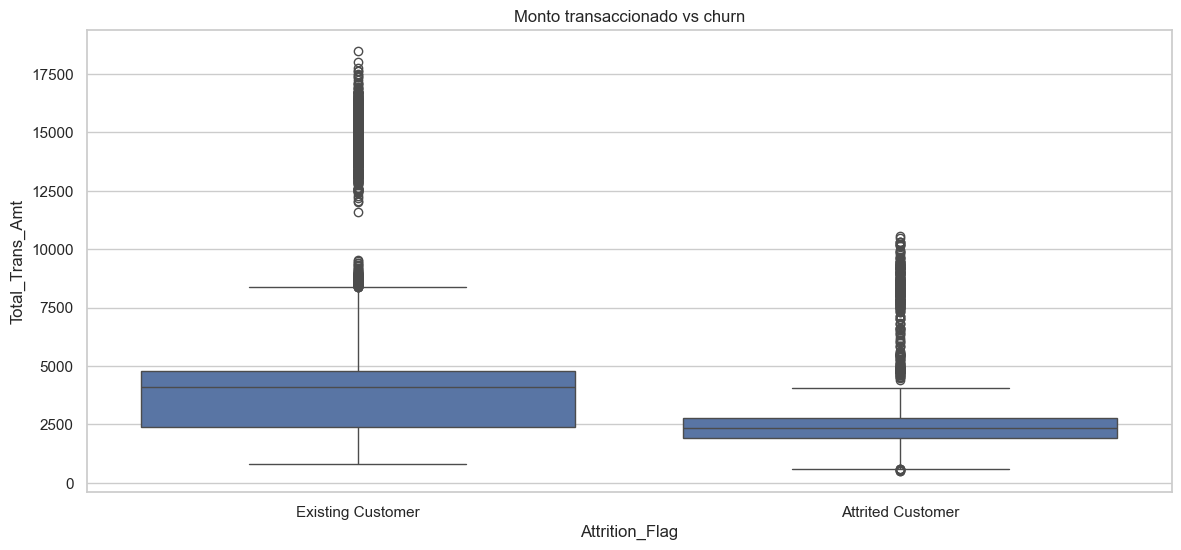

In [3]:
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=df)
plt.title('Monto transaccionado vs churn')
plt.show()

Los que se van gastan menos dinero. Es la misma historia: actividad baja. Uso bajo. Se van.

Y hay clientes activos que gastan mucho. Esos son los que se quedan.

¿Outliers?

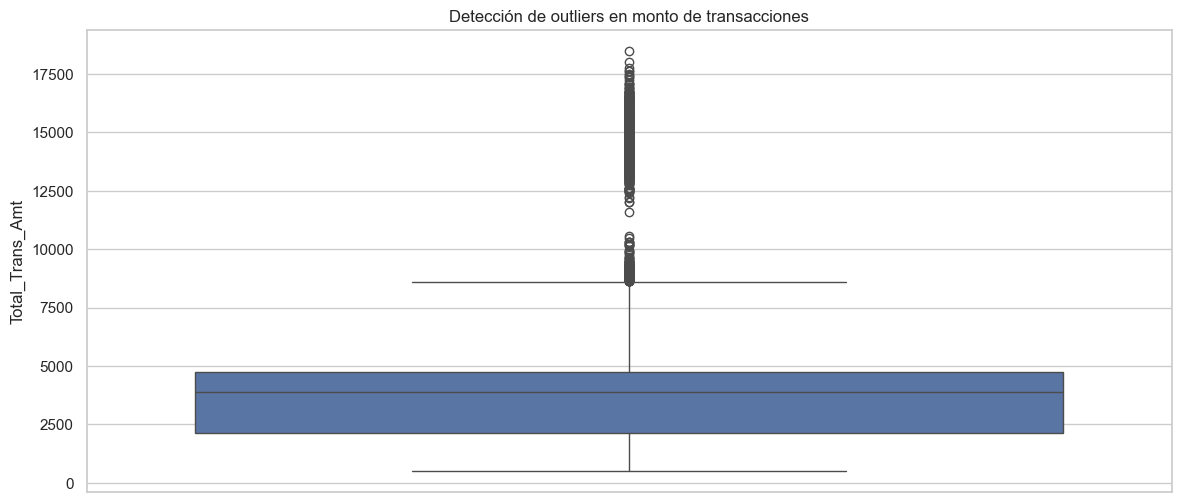

In [4]:
sns.boxplot(df['Total_Trans_Amt'])
plt.title('Detección de outliers en monto de transacciones')
plt.show()

Hay valores altos. No son errores. Son clientes que gastan mucho dinero. No se eliminan porque eso sería perder información valiosa. El modelo tiene que aprender a lidiar con esto.

¿Son los datos normales?

In [5]:
stat, p = shapiro(df['Total_Trans_Amt'].sample(500))
p

3.940330639295008e-26

No son normales. Es baja el p-value. Eso significa que no podemos asumir que la distribución es normal. Hay que usar pruebas que no dependan de eso.

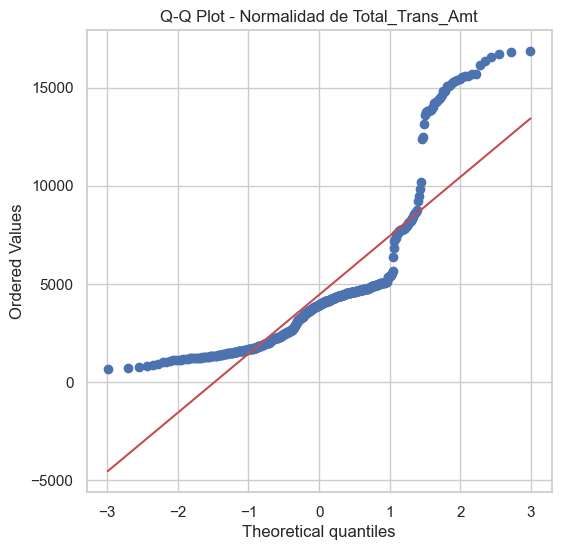

In [6]:
sample = df['Total_Trans_Amt'].sample(500, random_state=42)

plt.figure(figsize=(6,6))
stats.probplot(sample, dist="norm", plot=plt)
plt.title("Q-Q Plot - Normalidad de Total_Trans_Amt")
plt.show()

Este gráfico (Q-Q plot) compara qué tan cerca están los datos reales de una distribución normal. Los puntos deberían estar en la línea diagonal. Acá no, especialmente en los extremos. Eso confirma que no son normales.

Entonces usamos Mann-Whitney U en lugar de un t-test normal.

¿Es real la diferencia?

In [7]:
g1 = df[df['Attrition_Flag']=='Existing Customer']['Total_Trans_Amt']
g2 = df[df['Attrition_Flag']=='Attrited Customer']['Total_Trans_Amt']

stat, p = mannwhitneyu(g1, g2)
p

2.719009390771486e-112

Mann-Whitney U es una prueba que compara dos grupos sin asumir distribución normal.

Pregunta: ¿Los clientes que se van gastan diferente que los que se quedan?

La hipótesis nula dice: No, son iguales.
La hipótesis alternativa dice: Sí, son diferentes.

Si el p-value es menor a 0.05, rechazamos la nula. Significa que la diferencia es real, no por suerte.

Acá el p-value es menor a 0.05. Entonces rechazamos. La diferencia es real. Los que se van sí gastan menos.

Importante: Es una diferencia estadísticamente significativa, y además vimos en los gráficos que es una diferencia grande. No es apenas una diferencia técnica, es práctica.

¿Qué variables están relacionadas?

In [8]:
corr = df.corr(numeric_only=True)
corr.round(2)

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,1.00,0.01,0.01,0.13,0.01,0.01,0.01,0.01,0.00,0.01,0.02,-0.02,-0.00,0.01,0.00
Customer_Age,0.01,1.00,-0.12,0.79,-0.01,0.05,-0.02,0.00,0.01,0.00,-0.06,-0.05,-0.07,-0.01,0.01
Dependent_count,0.01,-0.12,1.00,-0.10,-0.04,-0.01,-0.04,0.07,-0.00,0.07,-0.04,0.03,0.05,0.01,-0.04
Months_on_book,0.13,0.79,-0.10,1.00,-0.01,0.07,-0.01,0.01,0.01,0.01,-0.05,-0.04,-0.05,-0.01,-0.01
Total_Relationship_Count,0.01,-0.01,-0.04,-0.01,1.00,-0.00,0.06,-0.07,0.01,-0.07,0.05,-0.35,-0.24,0.04,0.07
Months_Inactive_12_mon,0.01,0.05,-0.01,0.07,-0.00,1.00,0.03,-0.02,-0.04,-0.02,-0.03,-0.04,-0.04,-0.04,-0.01
Contacts_Count_12_mon,0.01,-0.02,-0.04,-0.01,0.06,0.03,1.00,0.02,-0.05,0.03,-0.02,-0.11,-0.15,-0.09,-0.06
Credit_Limit,0.01,0.00,0.07,0.01,-0.07,-0.02,0.02,1.00,0.04,1.00,0.01,0.17,0.08,-0.00,-0.48
Total_Revolving_Bal,0.00,0.01,-0.00,0.01,0.01,-0.04,-0.05,0.04,1.00,-0.05,0.06,0.06,0.06,0.09,0.62
Avg_Open_To_Buy,0.01,0.00,0.07,0.01,-0.07,-0.02,0.03,1.00,-0.05,1.00,0.01,0.17,0.07,-0.01,-0.54


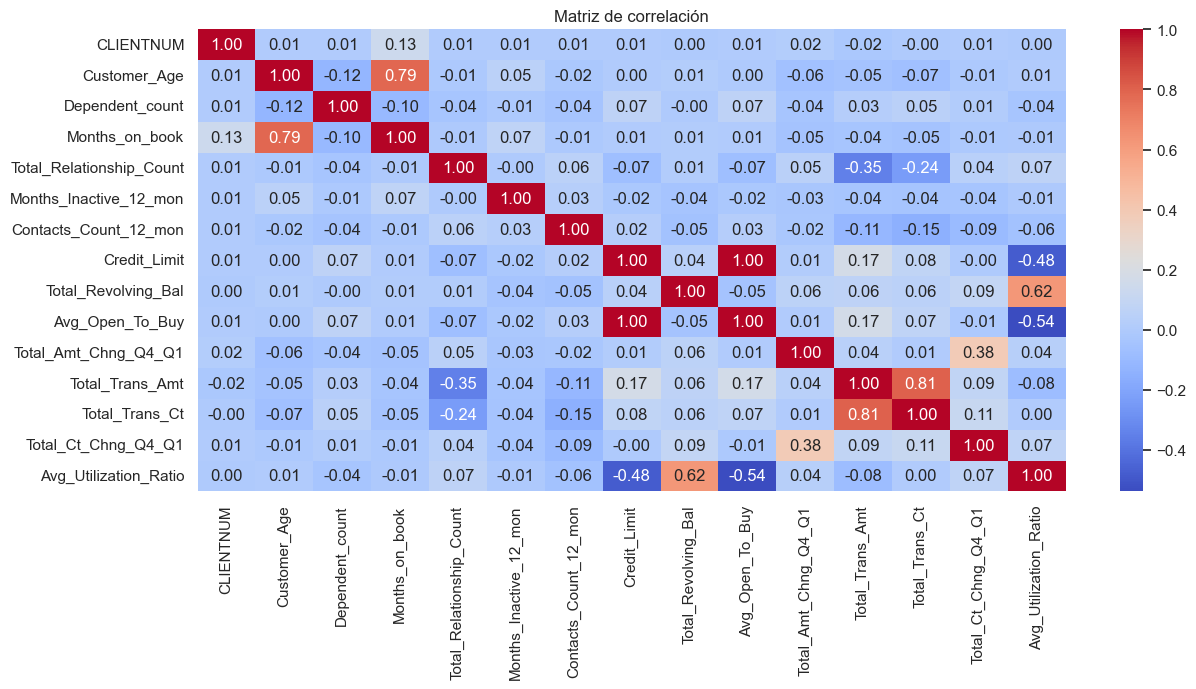

In [9]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

La matriz muestra correlación entre variables. Valores cercanos a 1 = muy relacionadas. Cercanos a 0 = no relacionadas.

Ves Credit_Limit y Avg_Open_To_Buy? Casi perfecta correlación (0.99). Eso significa que son matemáticamente la misma cosa. Si eliminas una, no pierdes nada. Hay que sacar una.

Total_Trans_Ct y Total_Trans_Amt tienen correlación moderada (0.8). Capturan cosas diferentes: uno es cantidad de transacciones, otro es el dinero. Ambas importan.

Multicolinealidad (¿variables que dicen lo mismo?)

In [10]:
num = df.select_dtypes(include=np.number).drop(columns=['CLIENTNUM'])
vif = pd.DataFrame()
vif['Variable'] = num.columns
vif['VIF'] = [variance_inflation_factor(num.values, i) for i in range(len(num.columns))]
vif.sort_values('VIF', ascending=False)

c:\Users\monte\OneDrive\Documentos\ProjectML Churn\venv_clean\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
6,Credit_Limit,inf
7,Total_Revolving_Bal,inf
8,Avg_Open_To_Buy,inf
0,Customer_Age,75.090540
2,Months_on_book,56.437261
11,Total_Trans_Ct,23.199897
9,Total_Amt_Chng_Q4_Q1,13.940730
12,Total_Ct_Chng_Q4_Q1,11.808382
10,Total_Trans_Amt,8.635042
3,Total_Relationship_Count,7.476147


VIF alto = variable redundante. Si VIF es infinito (como Avg_Open_To_Buy), es una variable que se puede calcular perfectamente a partir de otra. Hay que sacarla.

Qué encontramos?

Lo importante:

1. Los que se van son realmente diferentes: gastan menos, hacen menos movimientos, menos activos. No es por suerte.

2. Variables que dicen lo mismo: Credit_Limit y Avg_Open_To_Buy. Hay que eliminar una.

3. Los datos no son normales, así que usamos pruebas no-paramétricas.

4. El comportamiento transaccional es lo que más importa. Los datos demográficos (edad, género, ingresos) parecen menos importantes.